# 📊 Dashboard Executivo de Vendas - Olist

## Análise Exploratória dos Dados (EDA)

**Autor:** Alef Nascimento Soares Silva de Sousa

---

## Objetivo

Este notebook apresenta a etapa de Análise Exploratória dos Dados (EDA) realizada antes do desenvolvimento do Dashboard Executivo em Power BI.

Nesta fase foram executadas atividades como:

- Configuração do ambiente de desenvolvimento
- Importação das bibliotecas
- Leitura dos datasets
- Exploração inicial dos dados
- Verificação da qualidade das informações
- Identificação de valores ausentes
- Planejamento da modelagem dimensional
- Definição dos indicadores estratégicos utilizados no dashboard

Ao final desta etapa foi possível estruturar a base necessária para construção do Dashboard Executivo de Vendas do marketplace Olist.

# 1. Configuração do Ambiente

Antes de iniciar a análise foi realizada a configuração do ambiente Python e verificação do correto funcionamento das bibliotecas necessárias para o projeto.

In [1]:
print("Olá, Alef! Ambiente funcionando!")

Olá, Alef! Ambiente funcionando!


# 2. Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas durante a análise exploratória.

O projeto utiliza principalmente a biblioteca **Pandas**, responsável pela leitura, manipulação e análise dos dados.

In [1]:
# Importação da biblioteca principal

import pandas as pd

# Verificando a versão instalada

print(f"Versão do Pandas: {pd.__version__}")

Versão do Pandas: 3.0.4


# 3. Carregamento dos Dados

O primeiro conjunto de dados analisado corresponde à tabela de clientes.

Nesta etapa os dados são carregados para um DataFrame do Pandas, permitindo a exploração das informações armazenadas no dataset.

In [2]:
# Leitura da tabela de clientes

clientes = pd.read_csv("../Dataset/olist_customers_dataset.csv")

# Visualização das primeiras linhas

clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


# 4. Conhecendo a Estrutura dos Dados

Após o carregamento da base, foi realizada uma inspeção inicial da estrutura do dataset.

Esta análise permite identificar:

- Quantidade de registros;
- Tipos de dados;
- Valores ausentes;
- Estrutura geral das colunas.

In [4]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


# 5. Estatísticas Descritivas

Nesta etapa são apresentadas estatísticas gerais da base de clientes.

O objetivo é compreender a distribuição das informações e identificar possíveis inconsistências antes do processo de modelagem.

In [5]:
clientes.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


## 5.1 Avaliação da Qualidade dos Dados

Após compreender a estrutura da tabela de clientes, foi realizada uma análise da qualidade dos dados.

Nesta etapa foram verificadas:

- Existência de valores ausentes;
- Distribuição dos clientes por estado;
- Estados com maior concentração de clientes;
- Representatividade percentual de cada estado na base.

Essa análise permitiu compreender melhor a distribuição geográfica dos clientes e validar a consistência das informações antes da modelagem.

In [6]:
clientes.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [7]:
clientes["customer_state"].value_counts()


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [8]:
clientes["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [9]:
clientes["customer_state"].value_counts(normalize=True) * 100

customer_state
SP    41.980672
RJ    12.924247
MG    11.700405
RS     5.496727
PR     5.073360
SC     3.657445
BA     3.399000
DF     2.152030
ES     2.044428
GO     2.031355
PE     1.661287
CE     1.343510
PA     0.980481
MT     0.912099
MA     0.751199
MS     0.719019
PB     0.539013
PI     0.497783
RN     0.487726
AL     0.415322
SE     0.351967
TO     0.281574
RO     0.254422
AM     0.148832
AC     0.081455
AP     0.068382
RR     0.046259
Name: proportion, dtype: float64

### Principais Observações

A análise demonstrou que:

- A base apresenta boa qualidade para utilização nas análises.
- Os clientes estão distribuídos entre diversos estados brasileiros.
- Alguns estados concentram uma parcela significativamente maior dos clientes, informação que posteriormente foi utilizada na construção dos indicadores geográficos do dashboard.

# 6. Exploração da Tabela de Pedidos

A tabela de pedidos representa uma das principais entidades do projeto, armazenando informações sobre cada compra realizada no marketplace.

Nesta etapa foi realizada a importação da base e uma inspeção inicial dos registros para compreender sua estrutura e identificar as principais colunas utilizadas na modelagem dimensional.

In [10]:
orders = pd.read_csv("../Dataset/olist_orders_dataset.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Estrutura da Tabela

Foi realizada uma inspeção da estrutura da tabela para identificar:

- Quantidade de registros;
- Tipos de dados;
- Colunas disponíveis;
- Existência de valores ausentes.

In [11]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


### Análise dos Status dos Pedidos

Nesta etapa foi analisada a distribuição dos pedidos por status.

O objetivo foi compreender o comportamento operacional do marketplace e identificar a proporção de pedidos entregues, cancelados e demais situações registradas na base.

In [12]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [13]:
orders["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [14]:
orders[orders["order_status"] == "delivered"].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [15]:
orders[orders["order_status"] == "canceled"]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaN,NaN,2018-08-14 00:00:00
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaN,2018-02-22 00:00:00
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaN,2018-02-23 00:00:00
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
...,...,...,...,...,...,...,...,...
98791,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaN,NaN,2017-03-30 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99143,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaN,NaN,2017-10-27 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


### Principais Observações

Foi observado que a maior parte dos pedidos possui status **Entregue**, indicando uma elevada taxa de conclusão das vendas.

Essa informação foi utilizada posteriormente na construção do indicador **Percentual de Pedidos Entregues** presente no dashboard.

# 7. Exploração da Tabela de Itens do Pedido

A tabela de itens do pedido registra cada produto vendido em uma compra.

Esta tabela foi utilizada para calcular indicadores financeiros como faturamento, ticket médio e volume de vendas.

In [16]:
order_items = pd.read_csv("../Dataset/olist_order_items_dataset.csv")

order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### Estrutura da Tabela

Foi realizada uma inspeção inicial da estrutura da tabela para identificar os campos necessários aos cálculos financeiros do projeto.

In [17]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


# 8. Construção dos Indicadores de Negócio

Com os dados já explorados, foram desenvolvidos os principais indicadores estratégicos que posteriormente seriam apresentados no Dashboard Executivo.

Os KPIs calculados foram:

- Receita Total;
- Total de Pedidos;
- Clientes Únicos;
- Ticket Médio.

In [25]:
# KPI 1 - Faturamento
faturamento_total = order_items["price"].sum()

# KPI 2 - Total de Pedidos
total_pedidos = order_items["order_id"].nunique()

# KPI 3 - Clientes Únicos
clientes_unicos = clientes["customer_unique_id"].nunique()

# KPI 4 - Ticket Médio
ticket_medio = faturamento_total / total_pedidos

print("=" * 50)
print("KPIs DA TECHSTOREBRASIL")
print("=" * 50)

print(f"Faturamento Total : R$ {faturamento_total:,.2f}")
print(f"Total de Pedidos  : {total_pedidos:,}")
print(f"Clientes Únicos   : {clientes_unicos:,}")
print(f"Ticket Médio      : R$ {ticket_medio:.2f}")

KPIs DA TECHSTOREBRASIL
Faturamento Total : R$ 13,591,643.70
Total de Pedidos  : 98,666
Clientes Únicos   : 96,096
Ticket Médio      : R$ 137.75


### Resultado

Os indicadores calculados nesta etapa serviram como base para os cartões executivos apresentados na primeira página do dashboard.

# 9. Exploração da Tabela de Produtos

A tabela de produtos foi utilizada para complementar as informações comerciais e permitir análises por categoria de produto.

In [27]:
products = pd.read_csv("../Dataset/olist_products_dataset.csv")

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### Integração das Bases

Foi realizado o relacionamento entre os itens do pedido e a tabela de produtos.

Essa integração possibilitou calcular o faturamento por categoria de produto.

In [28]:
vendas = order_items.merge(
    products,
    on="product_id",
    how="left"
)

vendas.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


### Receita por Categoria

Após a integração das tabelas foi calculado o faturamento total por categoria de produto.

Essa análise permitiu identificar os segmentos responsáveis pela maior geração de receita no marketplace.

In [31]:
categorias = (
    vendas
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

categorias.columns = ["Categoria", "Faturamento"]

categorias["Faturamento"] = categorias["Faturamento"].map(lambda x: f"R$ {x:,.2f}")

categorias.head(10)

,Categoria,Faturamento
0,beleza_saude,"R$ 1,258,681.34"
1,relogios_presentes,"R$ 1,205,005.68"
2,cama_mesa_banho,"R$ 1,036,988.68"
3,esporte_lazer,"R$ 988,048.97"
4,informatica_acessorios,"R$ 911,954.32"
5,moveis_decoracao,"R$ 729,762.49"
6,cool_stuff,"R$ 635,290.85"
7,utilidades_domesticas,"R$ 632,248.66"
8,automotivo,"R$ 592,720.11"
9,ferramentas_jardim,"R$ 485,256.46"


# 10. Visualização dos Dados

Após a construção dos indicadores, foram elaboradas visualizações gráficas para validar os resultados da análise exploratória.

Esses gráficos permitiram identificar padrões de vendas, concentração de receita e comportamento das categorias de produtos.

In [32]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [33]:
top10 = (
    vendas
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

## 10.1 Top 10 Categorias por Receita

Foi desenvolvido um gráfico de barras apresentando as dez categorias com maior faturamento.

Essa análise auxiliou na identificação dos segmentos mais relevantes do marketplace e posteriormente serviu de referência para a construção dos visuais do dashboard em Power BI.

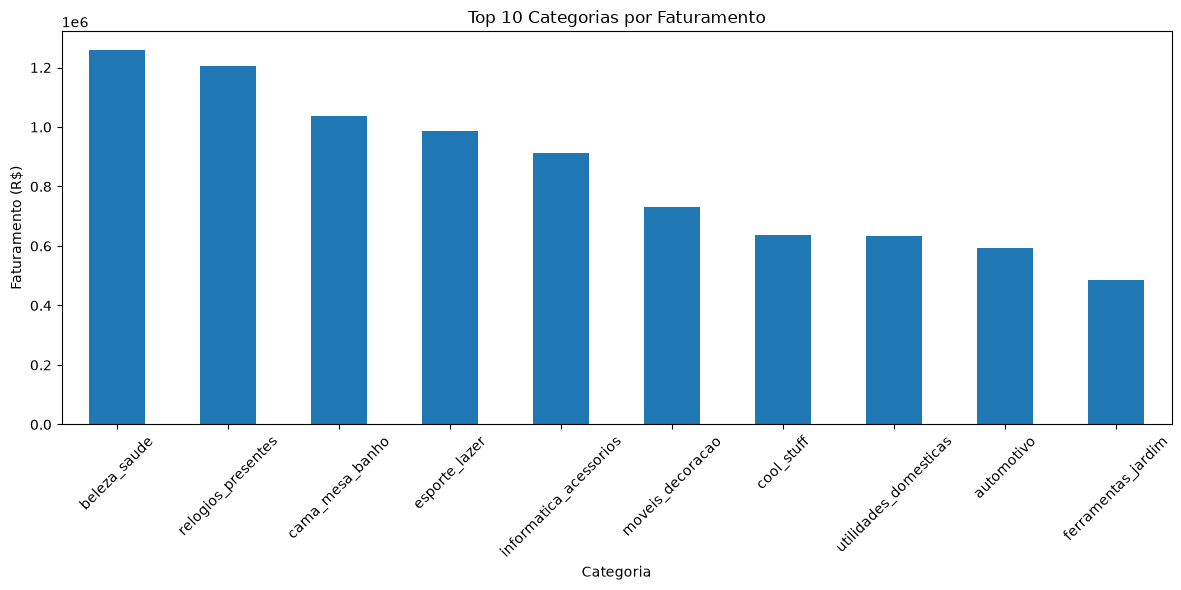

In [34]:
plt.figure(figsize=(12,6))

top10.plot(kind="bar")

plt.title("Top 10 Categorias por Faturamento")

plt.xlabel("Categoria")

plt.ylabel("Faturamento (R$)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 10.2 Quantidade Vendida por Categoria

Além da receita, também foi analisado o volume de produtos vendidos por categoria.

Essa comparação permite identificar diferenças entre categorias com alto faturamento e categorias com grande volume de vendas.

In [35]:
categorias_qtd = (
    vendas
    .groupby("product_category_name")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Quantidade Vendida")
)

categorias_qtd.head(10)

,product_category_name,Quantidade Vendida
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


## 10.3 Ticket Médio por Categoria

Foi calculado o ticket médio das categorias de produtos, permitindo identificar segmentos com maior valor médio por venda.

Essa análise auxilia na compreensão do comportamento financeiro das diferentes categorias comercializadas.

In [36]:
ticket_categoria = (
    vendas
    .groupby("product_category_name")["price"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

ticket_categoria.columns = ["Categoria", "Ticket Médio"]

ticket_categoria.head(10)

,Categoria,Ticket Médio
0,pcs,1098.340542
1,portateis_casa_forno_e_cafe,624.285658
2,eletrodomesticos_2,476.124958
3,agro_industria_e_comercio,342.124858
4,instrumentos_musicais,281.616000
5,eletroportateis,280.778468
6,portateis_cozinha_e_preparadores_de_alimentos,264.568667
7,telefonia_fixa,225.693182
8,construcao_ferramentas_seguranca,208.992371
9,relogios_presentes,201.135984


# 11. Integração das Bases

Para possibilitar análises geográficas foi realizada a integração entre as tabelas de:

- Itens do Pedido;
- Pedidos;
- Clientes.

Essa etapa permitiu relacionar as vendas aos estados dos clientes e calcular indicadores regionais.

In [37]:
vendas_estado = (
    order_items
    .merge(orders, on="order_id", how="left")
    .merge(clientes, on="customer_id", how="left")
)

In [38]:
vendas_estado.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


## 11.1 Receita por Estado

Com a base integrada foi calculado o faturamento por estado dos clientes.

Essa informação foi utilizada posteriormente para construção das análises regionais no dashboard.

In [41]:
faturamento_estado = (
    vendas_estado
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

faturamento_estado.columns = ["Estado", "Faturamento"]

faturamento_estado.head(10)

,Estado,Faturamento
0,SP,5202955.05
1,RJ,1824092.67
2,MG,1585308.03
3,RS,750304.02
4,PR,683083.76
5,SC,520553.34
6,BA,511349.99
7,DF,302603.94
8,GO,294591.95
9,ES,275037.31


# Conclusão

A etapa de Análise Exploratória dos Dados permitiu compreender a estrutura da base do Olist e identificar os principais indicadores estratégicos utilizados no desenvolvimento do Dashboard Executivo.

Durante o processo foram realizadas atividades de:

- exploração dos datasets;
- verificação da qualidade dos dados;
- integração entre tabelas;
- construção dos principais KPIs;
- identificação dos principais padrões de vendas.

Os resultados desta análise serviram como base para a modelagem dimensional e para o desenvolvimento do dashboard em Power BI.

## Próxima Etapa

Após a conclusão da Análise Exploratória dos Dados, iniciou-se o desenvolvimento do Dashboard Executivo utilizando Power BI.

As principais atividades desta etapa foram:

- Modelagem Dimensional (Star Schema);
- Transformações no Power Query;
- Construção de medidas em DAX;
- Desenvolvimento dos indicadores executivos;
- Criação das visualizações interativas.